# 24AI633 - Probabilistic Graphical Models

## Name: Nikhil Rajiv
## Roll No: CB.SC.P2AIE25014

The problem is to analyse how environmental and physiological factors, such as noise level and screen fatigue, influence student learning performance and focus. To address this, a Bayesian Network is used to model probabilistic relationships between the variables, while D-separation is applied to study conditional independence. Network visualization is used to clearly represent and interpret the dependency structure.

In [5]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt

In [6]:
model = DiscreteBayesianNetwork([
    ('NoiseLevel', 'AttentionLevel'),
    ('ScreenFatigue', 'AttentionLevel'),
    ('AttentionLevel', 'NoteQuality'),
    ('AttentionLevel', 'TestPerformance')
])

In [7]:
cpd_noise = TabularCPD(
    variable='NoiseLevel',
    variable_card=2,
    values=[[0.6], [0.4]]
)

In [8]:
cpd_fatigue = TabularCPD(
    variable='ScreenFatigue',
    variable_card=2,
    values=[[0.5], [0.5]]
)

In [9]:
cpd_attention = TabularCPD(
    variable='AttentionLevel',
    variable_card=2,
    values=[
        [0.8, 0.6, 0.7, 0.2],
        [0.2, 0.4, 0.3, 0.8]
    ],
    evidence=['NoiseLevel', 'ScreenFatigue'],
    evidence_card=[2, 2]
)

In [10]:
cpd_notes = TabularCPD(
    variable='NoteQuality',
    variable_card=2,
    values=[
        [0.7, 0.2],
        [0.3, 0.8]
    ],
    evidence=['AttentionLevel'],
    evidence_card=[2]
)

In [11]:
cpd_test = TabularCPD(
    variable='TestPerformance',
    variable_card=2,
    values=[
        [0.75, 0.25],
        [0.25, 0.75]
    ],
    evidence=['AttentionLevel'],
    evidence_card=[2]
)

In [12]:
model.add_cpds(
    cpd_noise,
    cpd_fatigue,
    cpd_attention,
    cpd_notes,
    cpd_test
)

print("Model Valid:", model.check_model())

Model Valid: True


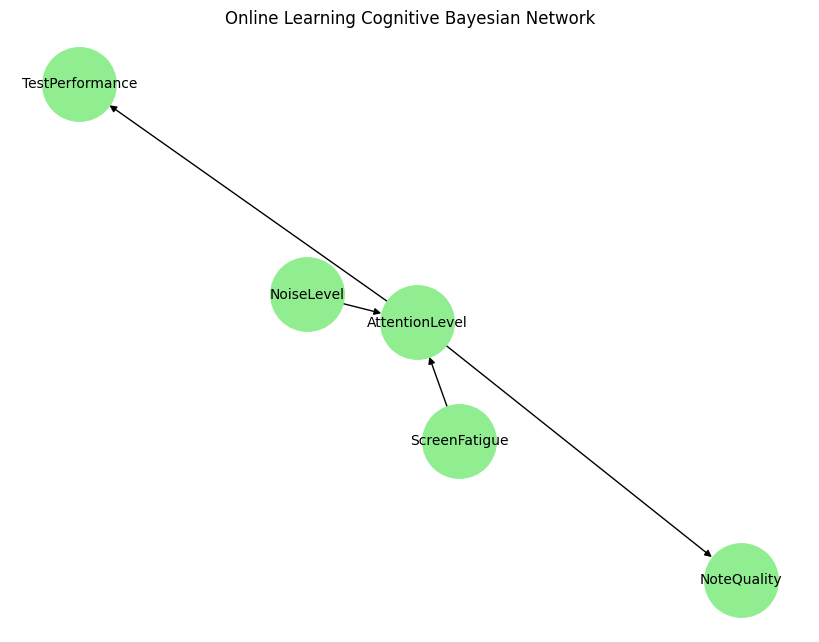

In [20]:
def visualize_network(model):

    G = nx.DiGraph()
    G.add_edges_from(model.edges())

    pos = nx.spring_layout(G)

    plt.figure(figsize=(8,6))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color='lightgreen',
        node_size=2800,
        font_size=10,
        arrows=True
    )

    plt.title("Online Learning Cognitive Bayesian Network")
    plt.show()

visualize_network(model)

In [21]:
inference = VariableElimination(model)

result = inference.query(
    variables=['TestPerformance'],
    evidence={'NoiseLevel': 1, 'ScreenFatigue': 0}
)

print(result)

+--------------------+------------------------+
| TestPerformance    |   phi(TestPerformance) |
+====================+========================+
| TestPerformance(0) |                 0.6000 |
+--------------------+------------------------+
| TestPerformance(1) |                 0.4000 |
+--------------------+------------------------+


In [22]:
print(
    "NoiseLevel and ScreenFatigue Independent?",
    not model.is_dconnected('NoiseLevel', 'ScreenFatigue')
)

NoiseLevel and ScreenFatigue Independent? True


In [26]:
print(
    "NoiseLevel and NoteQuality are conditionally independent given AttentionLevel ?",
    not model.is_dconnected(
        'NoiseLevel',
        'NoteQuality',
        observed=['AttentionLevel']
    )
)

NoiseLevel and NoteQuality are conditionally independent given AttentionLevel ? True
